# 01 — Discovery y perfilado de datos

Proyecto **CRM + Billing + Universidad** — análisis exploratorio sobre los 18 CSV crudos de `data/raw/`.

**Fecha de análisis:** 2026-07-20

Este notebook documenta el perfilado completo de los datos de origen **antes de cualquier transformación**: inventario, perfilado por tabla, integridad referencial, reglas de negocio por dominio y relaciones cross-dominio. Cada sección cierra con una conclusión y la acción propuesta para la capa Silver.

> Ejecutable dentro del contenedor Jupyter del proyecto (`docker compose up`): los datos están montados en `/home/jovyan/data/raw`. Fuera del contenedor resuelve la ruta relativa `../data/raw`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('/home/jovyan/data/raw')
if not RAW.exists():
    RAW = Path('../data/raw')

# Fecha de corte explícita para que métricas de vigencia sean reproducibles.
ANALYSIS_DATE = pd.Timestamp('2026-07-21')

FILES = {
    'university': ['semesters', 'professors', 'students', 'courses', 'enrollments', 'grades'],
    'billing':    ['customers', 'products', 'subscriptions', 'invoices', 'invoice_items', 'payments'],
    'crm':        ['accounts', 'contacts', 'leads', 'opportunities', 'opportunity_contacts', 'activities'],
}

def load(domain, table):
    # dtype=str: en discovery no imponemos tipos, leemos el crudo tal cual
    return pd.read_csv(RAW / domain / f'{table}.csv', dtype=str,
                       keep_default_na=False, na_values=[''])

data = {(d, t): load(d, t) for d, tables in FILES.items() for t in tables}
print(f'{len(data)} tablas cargadas desde {RAW}')

18 tablas cargadas desde /home/jovyan/data/raw


## 1. Inventario

Primer control: ¿recibimos lo que dice el `manifest.json` del generador? (conteos esperados hardcodeados aquí porque el manifest no está montado en el contenedor).

In [2]:
EXPECTED = {
    ('university', 'semesters'): 8,     ('university', 'professors'): 200,
    ('university', 'students'): 5000,   ('university', 'courses'): 300,
    ('university', 'enrollments'): 25000, ('university', 'grades'): 60000,
    ('billing', 'customers'): 10000,    ('billing', 'products'): 200,
    ('billing', 'subscriptions'): 15000, ('billing', 'invoices'): 50000,
    ('billing', 'invoice_items'): 150000, ('billing', 'payments'): 80000,
    ('crm', 'accounts'): 5000,          ('crm', 'contacts'): 15000,
    ('crm', 'leads'): 2000,             ('crm', 'opportunities'): 3000,
    ('crm', 'opportunity_contacts'): 6000, ('crm', 'activities'): 20000,
}

inv = pd.DataFrame([
    {'dominio': d, 'tabla': t, 'filas': len(df), 'esperado': EXPECTED[(d, t)],
     'columnas': df.shape[1], 'MB': round((RAW / d / f'{t}.csv').stat().st_size / 1e6, 2)}
    for (d, t), df in data.items()
])
inv['ok'] = np.where(inv['filas'] == inv['esperado'], 'SI', 'NO')
print(f"Total filas: {inv['filas'].sum():,} | Tablas con conteo correcto: {(inv['ok']=='SI').sum()}/18")
inv

Total filas: 446,708 | Tablas con conteo correcto: 18/18


,dominio,tabla,filas,esperado,columnas,MB,ok
0,university,semesters,8,8,6,0.00,SI
1,university,professors,200,200,6,0.01,SI
2,university,students,5000,5000,7,0.41,SI
3,university,courses,300,300,6,0.02,SI
4,university,enrollments,25000,25000,6,1.57,SI
5,university,grades,60000,60000,6,3.30,SI
6,billing,customers,10000,10000,8,0.93,SI
7,billing,products,200,200,6,0.01,SI
8,billing,subscriptions,15000,15000,6,0.95,SI
9,billing,invoices,50000,50000,7,3.16,SI


**Conclusión:** las 18 tablas llegaron completas — 446,708 filas totales, 18/18 conteos idénticos al manifest. No hay pérdida de datos en la entrega.

## 2. Perfilado general — nulos y unicidad de claves

Para cada tabla: ¿la primera columna (`*_id`) es una PK real (única)? ¿qué columnas tienen nulos y cuántos?

In [3]:
rows = []
for (d, t), df in data.items():
    pk = df.columns[0]
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]
    rows.append({
        'dominio': d, 'tabla': t, 'pk': pk,
        'pk_duplicada': int(df[pk].duplicated().sum()),
        'columnas_con_nulos': ', '.join(f'{c}={n} ({n/len(df):.1%})' for c, n in nulls.items()) or '—',
    })
pd.DataFrame(rows)

,dominio,tabla,pk,pk_duplicada,columnas_con_nulos
0,university,semesters,semester_id,0,—
1,university,professors,professor_id,0,—
2,university,students,student_id,0,—
3,university,courses,course_id,0,—
4,university,enrollments,enrollment_id,0,—
5,university,grades,grade_id,0,—
6,billing,customers,customer_id,0,external_ref=5000 (50.0%)
7,billing,products,product_id,0,—
8,billing,subscriptions,subscription_id,0,—
9,billing,invoices,invoice_id,0,—


**Conclusión:** todas las PKs son 100% únicas (0 duplicados en las 18 tablas). Solo existen nulos en **3 columnas**, pero no todos pueden interpretarse aisladamente como opcionales intencionales:

- `customers.external_ref` — 5,000 (50%): no existe vínculo académico verificable para esos clientes.
- `activities.contact_id` — 5,976 (29.9%).
- `activities.opportunity_id` — 9,985 (49.9%).

Las dos FK de `activities` deben evaluarse conjuntamente: 7,020 filas tienen ambas, 7,004 solo contacto, 2,995 solo oportunidad y **2,981 no tienen ninguna relación**. En Silver se conservan los NULL, se deriva `activity_scope` y se flaggea `unlinked`; no se imputan ni eliminan automáticamente. `opportunity_contacts` usa PK compuesta `(opportunity_id, contact_id)`, verificada sin pares duplicados en la sección 7.

## 3. Integridad referencial

Verificación de huérfanos en las **18 relaciones FK** inferidas de las columnas `*_id` compartidas, incluidas las dos relaciones de `opportunity_contacts`.

In [4]:
FKS = [
    ('university', 'enrollments', 'student_id',  'university', 'students'),
    ('university', 'enrollments', 'course_id',   'university', 'courses'),
    ('university', 'enrollments', 'semester_id', 'university', 'semesters'),
    ('university', 'courses',     'professor_id','university', 'professors'),
    ('university', 'grades',      'enrollment_id','university','enrollments'),
    ('billing', 'subscriptions', 'customer_id', 'billing', 'customers'),
    ('billing', 'subscriptions', 'product_id',  'billing', 'products'),
    ('billing', 'invoices',      'customer_id', 'billing', 'customers'),
    ('billing', 'invoice_items', 'invoice_id',  'billing', 'invoices'),
    ('billing', 'invoice_items', 'product_id',  'billing', 'products'),
    ('billing', 'payments',      'invoice_id',  'billing', 'invoices'),
    ('crm', 'contacts',             'account_id',     'crm', 'accounts'),
    ('crm', 'opportunities',        'account_id',     'crm', 'accounts'),
    ('crm', 'opportunity_contacts', 'opportunity_id', 'crm', 'opportunities'),
    ('crm', 'opportunity_contacts', 'contact_id',     'crm', 'contacts'),
    ('crm', 'activities',           'contact_id',     'crm', 'contacts'),
    ('crm', 'activities',           'opportunity_id', 'crm', 'opportunities'),
    ('billing', 'customers', 'external_ref', 'university', 'students'),
]
rows = []
for cd, ct, col, pd_, pt in FKS:
    child = data[(cd, ct)][col].dropna()
    parent_pk = data[(pd_, pt)].columns[0] if col != 'external_ref' else 'student_id'
    orphans = int((~child.isin(data[(pd_, pt)][parent_pk])).sum())
    rows.append({'hija': f'{ct}.{col}', 'padre': f'{pt}.{parent_pk}',
                 'no_nulos': len(child), 'huerfanos': orphans})
fk = pd.DataFrame(rows)
print(f"Relaciones con huérfanos: {(fk['huerfanos'] > 0).sum()}/{len(FKS)}")
fk

Relaciones con huérfanos: 0/18


,hija,padre,no_nulos,huerfanos
0,enrollments.student_id,students.student_id,25000,0
1,enrollments.course_id,courses.course_id,25000,0
2,enrollments.semester_id,semesters.semester_id,25000,0
3,courses.professor_id,professors.professor_id,300,0
4,grades.enrollment_id,enrollments.enrollment_id,60000,0
5,subscriptions.customer_id,customers.customer_id,15000,0
6,subscriptions.product_id,products.product_id,15000,0
7,invoices.customer_id,customers.customer_id,50000,0
8,invoice_items.invoice_id,invoices.invoice_id,150000,0
9,invoice_items.product_id,products.product_id,150000,0


**Conclusión:** **0 huérfanos en las 18 relaciones verificadas**. La integridad *referencial* del dataset es excelente: toda FK no nula apunta a una fila existente. Esto no implica integridad de negocio; fechas, cuentas, importes y atributos relacionados presentan numerosas inconsistencias semánticas. Esa diferencia entre estructura y significado es la tesis central de este discovery.

## 4. Distribuciones clave

Estados y categorías principales de cada dominio.

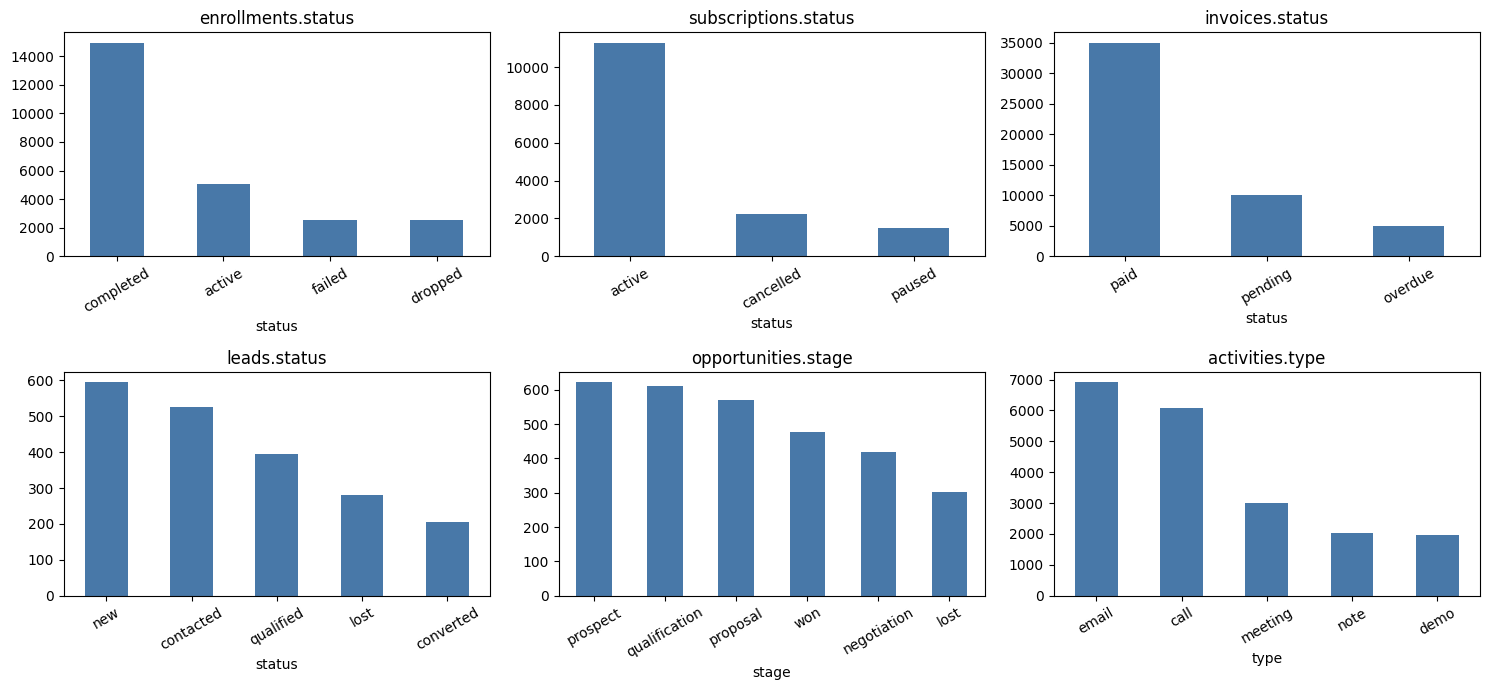

enrollments.status: completed=14931, active=5035, failed=2531, dropped=2503
subscriptions.status: active=11272, cancelled=2242, paused=1486
invoices.status: paid=34966, pending=10048, overdue=4986
leads.status: new=594, contacted=525, qualified=395, lost=281, converted=205
opportunities.stage: prospect=621, qualification=611, proposal=569, won=476, negotiation=420, lost=303
activities.type: email=6904, call=6093, meeting=3016, note=2028, demo=1959


In [5]:
dist = {
    'enrollments.status':    data[('university', 'enrollments')]['status'].value_counts(),
    'subscriptions.status':  data[('billing', 'subscriptions')]['status'].value_counts(),
    'invoices.status':       data[('billing', 'invoices')]['status'].value_counts(),
    'leads.status':          data[('crm', 'leads')]['status'].value_counts(),
    'opportunities.stage':   data[('crm', 'opportunities')]['stage'].value_counts(),
    'activities.type':       data[('crm', 'activities')]['type'].value_counts(),
}
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (title, s) in zip(axes.flat, dist.items()):
    s.plot.bar(ax=ax, color='#4878a8')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

for title, s in dist.items():
    print(f'{title}: ' + ', '.join(f'{k}={v}' for k, v in s.items()))

**Observaciones:**

- Catálogos limpios en todos los casos: sin nulos, sin valores fuera de dominio, sin problemas de casing.
- `opportunities`: tasa de victoria sobre cerradas = 476/(476+303) = **61.1%** — alta pero plausible en dato sintético.
- `subscriptions` no tiene estado `expired` (solo active/cancelled/paused) — relevante para la sección 6.
- `invoices`: 69.9% paid / 20.1% pending / 10.0% overdue. Ojo: el 100% de las `pending` ya tiene `due_at` vencida respecto a la fecha de análisis — el status es un snapshot congelado, no un estado vivo.

## 5. Universidad — reglas de negocio

### 5.1 Calificaciones: `score`, `weight` y duplicados de assessment

score : min=24.53 max=100.00 media=74.88 | fuera de [0,100]: 0
weight: min=0.10 max=0.50 | fuera de [0,1]: 0

Enrollments con notas: 22,786 | suma(weight) ~ 1.0: 141 (0.6%) | NO cumple: 22,645 (99.4%)
suma(weight): min=0.10 mediana=0.71 max=3.31

Enrollments SIN ninguna nota: 2,214 — por status: {'completed': 1303, 'active': 474, 'failed': 220, 'dropped': 217}

Grupos (enrollment, assessment) duplicados: 10,544 | filas involucradas: 22,867 (38.1% de grades)


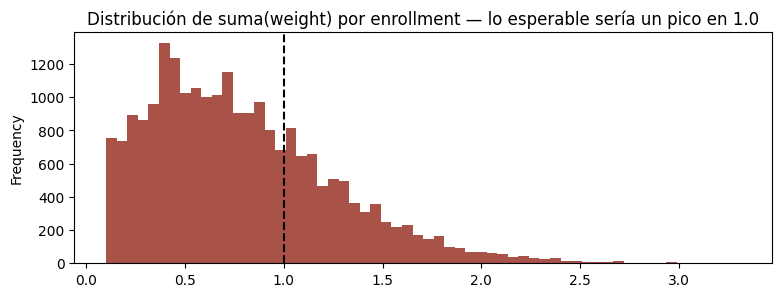

In [6]:
grd = data[('university', 'grades')].copy()
enr = data[('university', 'enrollments')]
grd['score'] = grd['score'].astype(float)
grd['weight'] = grd['weight'].astype(float)

print('score : min={:.2f} max={:.2f} media={:.2f} | fuera de [0,100]: {}'.format(
    grd.score.min(), grd.score.max(), grd.score.mean(), ((grd.score < 0) | (grd.score > 100)).sum()))
print('weight: min={:.2f} max={:.2f} | fuera de [0,1]: {}'.format(
    grd.weight.min(), grd.weight.max(), ((grd.weight < 0) | (grd.weight > 1)).sum()))

# La regla academica esperable: los pesos de un enrollment suman 1.0
wsum = grd.groupby('enrollment_id')['weight'].sum()
ok = (wsum - 1).abs() <= 0.01
print(f'\nEnrollments con notas: {len(wsum):,} | suma(weight) ~ 1.0: {ok.sum()} ({ok.mean():.1%})'
      f' | NO cumple: {(~ok).sum():,} ({(~ok).mean():.1%})')
print(f'suma(weight): min={wsum.min():.2f} mediana={wsum.median():.2f} max={wsum.max():.2f}')

sin_notas = enr[~enr.enrollment_id.isin(grd.enrollment_id)]
print(f'\nEnrollments SIN ninguna nota: {len(sin_notas):,} — por status: {sin_notas.status.value_counts().to_dict()}')

# Assessment repetido dentro del mismo enrollment (dos "midterm", dos "final"...)
per = grd.groupby(['enrollment_id', 'assessment']).size()
print(f'\nGrupos (enrollment, assessment) duplicados: {(per > 1).sum():,} '
      f'| filas involucradas: {per[per > 1].sum():,} ({per[per > 1].sum() / len(grd):.1%} de grades)')

wsum.plot.hist(bins=60, figsize=(9, 3), color='#a85248',
               title='Distribución de suma(weight) por enrollment — lo esperable sería un pico en 1.0')
plt.axvline(1.0, color='black', linestyle='--')
plt.show()

**Hallazgo crítico (grades):** los valores individuales son válidos (`score` en [24.5, 100], `weight` en [0.10, 0.50]) pero la estructura está rota:

1. La suma de `weight` por enrollment **casi nunca da 1.0** — solo 141 de 22,786 (0.6%). La suma va de 0.10 a 3.31 con mediana 0.71: los pesos fueron generados fila a fila sin coherencia por inscripción.
2. **10,544 combinaciones (enrollment, assessment) duplicadas** (22,867 filas, 38.1% de la tabla): una misma inscripción tiene dos "midterm" con notas distintas. No existe la estructura esperada de N assessments únicos.
3. **2,214 inscripciones sin ninguna nota**, incluidas 1,303 `completed` y 220 `failed` — estados finales sin evidencia de evaluación.

**Acción Silver:** no usar el promedio ponderado ingenuo. Calcular nota final como `sum(score·weight)/sum(weight)` (renormaliza el peso), tratar cada fila de grades como un *evento* de evaluación (no deduplicar a ciegas), y flags: `weight_sum_ok`, `has_duplicate_assessment`, `completed_without_grades`.

### 5.2 Inscripciones: fechas y duplicados lógicos

In [7]:
sem = data[('university', 'semesters')]
stu = data[('university', 'students')]
crs = data[('university', 'courses')]
prf = data[('university', 'professors')]

e = enr.merge(sem, on='semester_id')
ed, sd, fd = pd.to_datetime(e.enrolled_at), pd.to_datetime(e.start_date), pd.to_datetime(e.end_date)
en_ventana = ((ed >= sd) & (ed <= fd)).sum()
print(f'enrolled_at dentro de la ventana del semestre: {en_ventana:,}/{len(e):,} ({en_ventana/len(e):.1%})')
print(f'  antes del inicio: {(ed < sd).sum():,} ({(ed < sd).mean():.1%}) | después del fin: {(ed > fd).sum():,} ({(ed > fd).mean():.1%})')

dup = enr.groupby(['student_id', 'course_id', 'semester_id']).size()
print(f'\nInscripciones duplicadas (mismo alumno+curso+semestre): {(dup > 1).sum()} grupos, {dup[dup > 1].sum()} filas')

edad = (pd.to_datetime(stu.enrolled_at) - pd.to_datetime(stu.birth_date)).dt.days / 365.25
print(f'\nEstudiantes con <15 años al inscribirse: {(edad < 15).sum()} ({(edad < 15).mean():.1%}) | edad mínima: {edad.min():.1f}')

cp = crs.merge(prf, on='professor_id', suffixes=('_curso', '_prof'))
mm = cp[cp.department_curso != cp.department_prof]
print(f'Cursos cuyo profesor es de OTRO departamento: {len(mm)}/{len(crs)} ({len(mm)/len(crs):.0%}), '
      f'{mm.professor_id.nunique()} profesores involucrados')

enrolled_at dentro de la ventana del semestre: 2,271/25,000 (9.1%)
  antes del inicio: 11,648 (46.6%) | después del fin: 11,081 (44.3%)

Inscripciones duplicadas (mismo alumno+curso+semestre): 23 grupos, 46 filas

Estudiantes con <15 años al inscribirse: 636 (12.7%) | edad mínima: 10.2
Cursos cuyo profesor es de OTRO departamento: 264/300 (88%), 138 profesores involucrados


**Hallazgos (enrollments/students/courses):**

1. **`enrolled_at` no guarda relación con el semestre** — solo el 9.1% cae dentro de la ventana `[start_date, end_date]`; el resto se reparte mitad antes (hasta 1,308 días) y mitad después. *Acción Silver:* preservar ambas fechas y derivar `enrolled_at_out_of_window`; no reemplazar automáticamente el dato reportado por `semesters.start_date`.
2. **23 duplicados lógicos** (46 filas) de alumno+curso+semestre, 14 de ellos con status contradictorios (ej. `failed` y `completed` a la vez). *Acción Silver:* conservar y flaggear `is_duplicate_enrollment`; cualquier supervivencia o remapeo de grades requiere una decisión formal, porque el dataset no demuestra una prioridad de status correcta.
3. **636 estudiantes (12.7%) con menos de 15 años** al momento de `students.enrolled_at` (mínimo: 10.2 años) — `birth_date` y `enrolled_at` se generaron de forma independiente. *Acción Silver:* flag `age_at_enrollment_lt_15`; la edad no es confiable para analítica.
4. **88% de los cursos** tienen profesor de otro departamento — asignación consistente con azar. *Acción Silver:* flag informativo; para reporting, mantener separados el departamento del curso y el del profesor.
5. Lo que sí está limpio: `semesters` (8 filas coherentes como calendario), emails válidos y únicos en students/professors y `credits` en rango 2–6.

## 6. Billing — reglas de negocio

### 6.1 La cadena factura → items: ¿cuadra la aritmética?

In [8]:
inv = data[('billing', 'invoices')].copy()
itm = data[('billing', 'invoice_items')].copy()
for c in ['total']: inv[c] = inv[c].astype(float)
for c in ['line_total', 'quantity', 'unit_price']: itm[c] = itm[c].astype(float)

viol = ((itm.line_total - itm.quantity * itm.unit_price).abs() > 0.01).sum()
print(f'invoice_items: line_total != quantity*unit_price -> {viol} violaciones en {len(itm):,} filas')

isum = itm.groupby('invoice_id')['line_total'].sum()
invx = inv.set_index('invoice_id')
con_items = invx.index.intersection(isum.index)
diff = invx.loc[con_items, 'total'] - isum.loc[con_items]
mismatch = (diff.abs() > 0.01).sum()
corr = np.corrcoef(invx.loc[con_items, 'total'], isum.loc[con_items])[0, 1]
print(f'\ninvoices con items: {len(con_items):,} | total != suma(items): {mismatch:,} '
      f'({mismatch/len(con_items):.2%}) | correlación total~items: {corr:.4f}')
print(f'diferencia (total - items): media={diff.mean():.2f} mediana={diff.median():.2f} '
      f'min={diff.min():.2f} max={diff.max():.2f}')

sin_items = invx.index.difference(isum.index)
print(f'\ninvoices SIN items: {len(sin_items):,} ({len(sin_items)/len(inv):.1%}) '
      f'— por status: {invx.loc[sin_items, "status"].value_counts().to_dict()}')

invoice_items: line_total != quantity*unit_price -> 0 violaciones en 150,000 filas

invoices con items: 47,498 | total != suma(items): 47,497 (100.00%) | correlación total~items: -0.0046
diferencia (total - items): media=-599.74 mediana=-478.92 min=-5774.11 max=3772.15

invoices SIN items: 2,502 (5.0%) — por status: {'paid': 1774, 'pending': 481, 'overdue': 247}


**Hallazgo crítico (invoices):** la aritmética *interna* de los items es perfecta (`line_total = quantity × unit_price` en 150,000/150,000), pero **el `total` de la factura no cuadra con sus items en 47,497 de 47,498 casos**, con correlación ≈ 0. Además **2,502 facturas (5%) no tienen ningún item**.

La consistencia interna no convierte a los items en fuente única de revenue: solo 16/150,000 `unit_price` coinciden con `products.monthly_price` y únicamente 646 líneas corresponden a una suscripción vigente del cliente. **Acción Silver:** conservar `total_reported`, `line_sum` y `payment_sum` como medidas separadas con estados de reconciliación. Para facturas sin items, derivar `has_no_items`; no corregir ni descartar silenciosamente.

### 6.2 Pagos vs. facturas

In [9]:
pay = data[('billing', 'payments')].copy()
pay['amount'] = pay['amount'].astype(float)

# Comparación contable en centavos enteros para evitar artefactos de float.
pay['_amount_cents'] = (pay['amount'] * 100).round().astype('int64')
invoice_total_cents = (invx['total'] * 100).round().astype('int64')
psum = pay.groupby('invoice_id')['_amount_cents'].sum()
con_pagos = invx.index.intersection(psum.index)
d_cents = psum.loc[con_pagos] - invoice_total_cents.loc[con_pagos]
print(f'invoices con pagos: {len(con_pagos):,} | SIN ningún pago: {len(invx.index.difference(psum.index)):,}')
print(f'  sobrepagadas (>total): {(d_cents > 0).sum():,} ({(d_cents > 0).mean():.1%})')
print(f'  parciales   (<total): {(d_cents < 0).sum():,} ({(d_cents < 0).mean():.1%})')
print(f'  exactas a centavos  : {(d_cents == 0).sum():,}')
print(f'  dentro de ±1 centavo: {(d_cents.abs() <= 1).sum():,}')

paid = invx[invx.status == 'paid']
print(f"\nstatus='paid': {len(paid):,} | sin ningún pago registrado: {(~paid.index.isin(psum.index)).sum():,}")
print(f"pagos sobre facturas pending/overdue: "
      f"{invx.loc[con_pagos, 'status'].isin(['pending', 'overdue']).sum()}")
print(f"\nSanidad de payments: amount<=0: {(pay.amount <= 0).sum()} | "
      f"method: {pay.method.value_counts().to_dict()}")

invoices con pagos: 31,433 | SIN ningún pago: 18,567
  sobrepagadas (>total): 20,483 (65.2%)
  parciales   (<total): 10,948 (34.8%)
  exactas a centavos  : 2
  dentro de ±1 centavo: 8

status='paid': 34,966 | sin ningún pago registrado: 3,533
pagos sobre facturas pending/overdue: 0

Sanidad de payments: amount<=0: 0 | method: {'card': 43990, 'bank_transfer': 24054, 'paypal': 7987, 'cash': 3969}


**Hallazgo crítico (payments):** la direccionalidad por status es coherente (los pagos existen solo en facturas `paid`; pending/overdue tienen 0), pero la acumulación no reconcilia. A precisión de centavos, 20,483 facturas están por encima del total, 10,948 por debajo y solo 2 son exactas (8 dentro de ±1 centavo). Cada pago individual sí conserva relación con la factura: representa 20%–100% del total y ninguno lo supera; el sobrepago aparece al acumular varias fracciones. Además **3,533 facturas `paid` no tienen ningún pago registrado**.

**Acción Silver:** tratar `invoices.status` como declarativo y derivar `payment_reconciliation_status`; conservar `invoice_total_reported`, `line_sum` y `payment_sum` por separado. Ninguna de las tres medidas está demostrada como única fuente de revenue.

### 6.3 Suscripciones

In [10]:
sub = data[('billing', 'subscriptions')].copy()
prd = data[('billing', 'products')]
ssd, sed = pd.to_datetime(sub.start_date), pd.to_datetime(sub.end_date)

invertidas = sed < ssd
print(f'end_date < start_date: {invertidas.sum()} ({invertidas.mean():.1%}) '
      f'— por status: {sub[invertidas].status.value_counts().to_dict()}')
print(f'end_date nulos: {sub.end_date.isna().sum()} (0 esperado si end_date fuese fecha de baja...)')
act_venc = (sub.status == 'active') & (sed < ANALYSIS_DATE)
print(f"activas con end_date ya vencida: {act_venc.sum():,} ({act_venc.sum()/ (sub.status == 'active').sum():.1%} de las activas)")

inactivos = set(prd.loc[prd.active == 'False', 'product_id'])
sobre_inactivo = (sub.status == 'active') & sub.product_id.isin(inactivos)
print(f'suscripciones activas sobre productos inactivos: {sobre_inactivo.sum():,}')

end_date < start_date: 783 (5.2%) — por status: {'active': 583, 'cancelled': 103, 'paused': 97}
end_date nulos: 0 (0 esperado si end_date fuese fecha de baja...)
activas con end_date ya vencida: 7,154 (63.5% de las activas)
suscripciones activas sobre productos inactivos: 1,753


**Hallazgos (subscriptions):**

1. **783 suscripciones (5.2%) con `end_date` anterior a `start_date`**. *Acción Silver:* conservar las fechas reportadas y derivar `invalid_date_range`; no anular el valor original sin otra fuente.
2. `end_date` **nunca es nulo** (ni en las 11,272 activas): se comporta como fecha de fin programada, no como fecha de baja. Al 2026-07-21, **7,154 activas (63.5%)** ya están vencidas. *Acción Silver:* derivar `is_effectively_expired` usando una fecha de corte parametrizada, sin reescribir status.
3. **1,753 suscripciones activas apuntan a productos con `active=False`**. Puede ser legacy, pero requiere un flag de lifecycle; no se corrige automáticamente.

## 7. CRM — reglas de negocio

### 7.1 Oportunidades

In [11]:
opp = data[('crm', 'opportunities')].copy()
oc = data[('crm', 'opportunity_contacts')]
con = data[('crm', 'contacts')]
acc = data[('crm', 'accounts')]
act = data[('crm', 'activities')]
opp['amount'] = opp['amount'].astype(float)

atras = pd.to_datetime(opp.close_date) < pd.to_datetime(opp.created_at).dt.normalize()
print(f'close_date < created_at: {atras.sum():,}/{len(opp):,} ({atras.mean():.1%}) — afecta todos los stages:')
print('  ' + str(opp[atras].stage.value_counts().to_dict()))
print(f'close_date nulos: {opp.close_date.isna().sum()} (las abiertas también lo tienen: es fecha PROYECTADA de cierre)')
won = opp[opp.stage == 'won']
print(f"won: {len(won)} | won con amount<=0: {(won.amount <= 0).sum()} | amount min won: {won.amount.min():,.2f}")

sin_cont = ~opp.opportunity_id.isin(oc.opportunity_id)
print(f'\nOportunidades sin ningún contacto asociado: {sin_cont.sum()} ({sin_cont.mean():.1%})')

close_date < created_at: 1,029/3,000 (34.3%) — afecta todos los stages:
  {'prospect': 217, 'proposal': 206, 'qualification': 202, 'won': 175, 'negotiation': 134, 'lost': 95}
close_date nulos: 0 (las abiertas también lo tienen: es fecha PROYECTADA de cierre)
won: 476 | won con amount<=0: 0 | amount min won: 1,418.94

Oportunidades sin ningún contacto asociado: 414 (13.8%)


**Hallazgos (opportunities):** los montos están limpios (0 nulos, 0 ≤ 0, incluso en las 476 `won`), pero **1,029 oportunidades (34.3%) tienen `close_date` anterior a `created_at`**, repartidas en todos los stages — generación independiente de fechas. Y `close_date` está poblado también en las 2,221 abiertas: es una *fecha proyectada*, no real.

**Acción Silver:** flag `is_close_before_created` (sin corrección automática — no hay fuente de verdad); excluirlas de métricas de ciclo de venta. Derivar `closed_at` real solo para `won`/`lost`.

### 7.2 Las tablas de relación: el hallazgo más grave del dominio

In [12]:
# opportunity_contacts: el contacto pertenece a la MISMA cuenta que la oportunidad?
occ = (oc.merge(opp[['opportunity_id', 'account_id']], on='opportunity_id')
         .merge(con[['contact_id', 'account_id']], on='contact_id', suffixes=('_opp', '_con')))
mm = (occ.account_id_opp != occ.account_id_con).sum()
print(f'opportunity_contacts con contacto de OTRA cuenta: {mm:,}/{len(occ):,} ({mm/len(occ):.1%})')

# activities: composicion de FKs y coherencia de cuentas
ambos_null = act.contact_id.isna() & act.opportunity_id.isna()
ambos = act.contact_id.notna() & act.opportunity_id.notna()
print(f'\nactivities: ambos FK presentes: {ambos.sum():,} | solo contact: '
      f'{(act.contact_id.notna() & act.opportunity_id.isna()).sum():,} | solo opportunity: '
      f'{(act.contact_id.isna() & act.opportunity_id.notna()).sum():,} | AMBOS NULL (huérfanas): '
      f'{ambos_null.sum():,} ({ambos_null.mean():.1%})')
ab = (act[ambos].merge(opp[['opportunity_id', 'account_id']], on='opportunity_id')
                .merge(con[['contact_id', 'account_id']], on='contact_id', suffixes=('_opp', '_con')))
mm2 = (ab.account_id_opp != ab.account_id_con).sum()
print(f'activities (ambos FK) con contact y opportunity de cuentas DISTINTAS: {mm2:,}/{len(ab):,}')

print(f"\naccounts: {acc.name.nunique()} nombres distintos para {len(acc):,} cuentas "
      f"(top: {acc.name.value_counts().head(3).to_dict()})")
dup_em = con.email.str.lower().duplicated(keep=False).sum()
print(f'contacts con email duplicado: {dup_em} filas | cuentas sin contactos: '
      f'{(~acc.account_id.isin(con.account_id)).sum()}')

opportunity_contacts con contacto de OTRA cuenta: 5,995/6,000 (99.9%)

activities: ambos FK presentes: 7,020 | solo contact: 7,004 | solo opportunity: 2,995 | AMBOS NULL (huérfanas): 2,981 (14.9%)
activities (ambos FK) con contact y opportunity de cuentas DISTINTAS: 7,019/7,020

accounts: 599 nombres distintos para 5,000 cuentas (top: {'Patagonia Labs': 19, 'Pacific Logistics': 18, 'Pacific Cloud': 18})
contacts con email duplicado: 4 filas | cuentas sin contactos: 251


**Hallazgo crítico (relaciones CRM):** las FKs son válidas una a una, pero la *semántica* de las relaciones está rota:

1. **`opportunity_contacts`: 5,995 de 6,000 vínculos (99.9%) conectan un contacto con una oportunidad de OTRA cuenta** — solo 5 son coherentes. La tabla no sirve para análisis de buying committee sin una decisión de negocio explícita.
2. **`activities`: 7,019 de 7,020** actividades con ambos FKs vinculan contacto y oportunidad de cuentas distintas. Además **2,981 (14.9%) son huérfanas totales** (ambos FK nulos, no atribuibles a nadie).
3. `accounts.name`: solo **599 nombres distintos para 5,000 cuentas** (pool chico del generador) — el nombre **no** puede usarse como clave de negocio ni para deduplicar.
4. Menores: 4 contactos con email duplicado, 251 cuentas sin contactos, 414 oportunidades sin contactos.

**Acción Silver:** flags `account_mismatch` / `is_orphan`; para métricas por cuenta definir UNA regla de atribución (recomendada: vía `opportunity.account_id` cuando existe, si no vía `contact.account_id`) y documentarla en `decisiones.md`.

## 8. Cross-dominio: el puente University ↔ Billing y sus límites

In [13]:
cus = data[('billing', 'customers')]
led = data[('crm', 'leads')]

vinc = cus[cus.external_ref.notna()]
match = vinc.external_ref.isin(stu.student_id).sum()
posicional = (vinc.customer_id.str[4:].astype(int) == vinc.external_ref.str[4:].astype(int)).sum()
print(f'customers con external_ref: {len(vinc):,} | matchean student_id: {match:,} | '
      f'únicos: {vinc.external_ref.nunique():,} (relación 1:1 estricta)')
print(f'vínculo posicional CUS-n -> STU-n: {posicional:,}/5000')

pares = vinc.merge(stu, left_on='external_ref', right_on='student_id', suffixes=('_c', '_s'))
em = (pares.email_c.str.lower() == pares.email_s.str.lower()).sum()
nm = ((pares.first_name_c.str.lower() == pares.first_name_s.str.lower()) &
      (pares.last_name_c.str.lower() == pares.last_name_s.str.lower())).sum()
co = (pares.country_c == pares.country_s).sum()
print(f'\nConsistencia de atributos en los 5,000 pares student<->customer:')
print(f'  mismo email: {em} | mismo nombre completo: {nm} | mismo país: {co} ({co/len(pares):.1%} ~ azar 1/8)')

con_em = set(con.email.str.lower()); cus_em = set(cus.email.str.lower())
stu_em = set(stu.email.str.lower()); led_em = set(led.email.str.lower())
print(f'\nOverlap de emails entre dominios: contacts∩customers={len(con_em & cus_em)} | '
      f'leads∩contacts={len(led_em & con_em)} | leads∩customers={len(led_em & cus_em)} | '
      f'leads∩students={len(led_em & stu_em)}')
print(f"leads 'converted' (no rastreables a ningún destino): "
      f"{(led.status == 'converted').sum()}")

customers con external_ref: 5,000 | matchean student_id: 5,000 | únicos: 5,000 (relación 1:1 estricta)
vínculo posicional CUS-n -> STU-n: 5,000/5000

Consistencia de atributos en los 5,000 pares student<->customer:
  mismo email: 0 | mismo nombre completo: 1 | mismo país: 1072 (21.4% ~ azar 1/8)

Overlap de emails entre dominios: contacts∩customers=1 | leads∩contacts=0 | leads∩customers=0 | leads∩students=0
leads 'converted' (no rastreables a ningún destino): 205


**Hallazgo central del discovery:**

1. **El único puente real entre dominios es `customers.external_ref → students.student_id`**: 5,000 vínculos, 1:1 estricto, 0 huérfanos... y perfectamente *posicional* (`CUS-n → STU-n`, los primeros 5,000 customers). Es un artefacto del generador, pero es **confiable como FK técnica**.
2. **Los atributos de persona NO acompañan el vínculo**: en los 5,000 pares, 0 comparten email, solo 1 comparte nombre completo y el país coincide en 21.4% (≈ azar 1/8). El "student" y el "customer" vinculados son personas sintéticas distintas.
3. **No existe puente CRM↔Billing ni CRM↔University**: 1 solo email compartido entre contacts y customers (coincidencia), 0 entre leads y cualquier otra tabla. Los 205 leads `converted` no son rastreables a ningún contacto/cliente.

**Acción Silver/Gold:** modelar el vínculo como relación técnica entre dos entidades (`dim_customer.is_student` + FK a `dim_student`) **sin fusionar atributos de persona** (flag `person_attributes_mismatch`). No intentar identity resolution por email/nombre — sería matching espurio. El funnel de leads solo puede medirse por `status`, no por linkage. CRM se analiza como dominio independiente.

In [14]:
DATE_COLS = [
    ('university', 'students', 'birth_date'), ('university', 'students', 'enrolled_at'),
    ('university', 'professors', 'hired_at'), ('university', 'semesters', 'start_date'),
    ('university', 'semesters', 'end_date'), ('university', 'enrollments', 'enrolled_at'),
    ('university', 'grades', 'graded_at'),
    ('billing', 'customers', 'created_at'), ('billing', 'subscriptions', 'start_date'),
    ('billing', 'subscriptions', 'end_date'), ('billing', 'invoices', 'issued_at'),
    ('billing', 'invoices', 'due_at'), ('billing', 'payments', 'paid_at'),
    ('crm', 'accounts', 'created_at'), ('crm', 'contacts', 'created_at'),
    ('crm', 'leads', 'created_at'), ('crm', 'opportunities', 'created_at'),
    ('crm', 'opportunities', 'close_date'), ('crm', 'activities', 'occurred_at'),
]
rows = []
for d, t, c in DATE_COLS:
    s = pd.to_datetime(data[(d, t)][c].dropna())
    rows.append({'columna': f'{t}.{c}', 'min': s.min().date(), 'max': s.max().date(),
                 'futuras': int((s > ANALYSIS_DATE).sum())})
fechas = pd.DataFrame(rows)
print('Única columna con fechas futuras: subscriptions.end_date (fin de vigencia programado — válido)')
fechas

Única columna con fechas futuras: subscriptions.end_date (fin de vigencia programado — válido)


,columna,min,max,futuras
0,students.birth_date,1995-01-01,2007-12-31,0
1,students.enrolled_at,2018-01-01,2025-09-30,0
2,professors.hired_at,2005-03-10,2024-12-27,0
3,semesters.start_date,2022-03-01,2025-08-01,0
4,semesters.end_date,2022-07-15,2025-12-15,0
5,enrollments.enrolled_at,2022-01-01,2025-12-31,0
6,grades.graded_at,2022-02-01,2025-12-31,0
7,customers.created_at,2018-01-01,2025-12-30,0
8,subscriptions.start_date,2020-01-01,2025-06-30,0
9,subscriptions.end_date,2024-01-01,2027-12-31,5509


**Rango temporal del negocio:** 2005-03-10 (`hired_at` mínimo) → 2027-12-31 (`end_date` máximo de suscripciones). La única columna con fechas futuras es `subscriptions.end_date` (5,518 filas — fin de vigencia programado, no error). `birth_date` (1995–2007) se trata como atributo de `dim_student`, fuera del calendario operacional.

**Para Gold:** `dim_date` de 2005-01-01 a 2027-12-31.

## 9. Síntesis — mapa de hallazgos y acciones para Silver

**Tesis del discovery:** el dataset tiene integridad *referencial* excelente (18 FK sin huérfanos y PK únicas), pero numerosas relaciones carecen de coherencia semántica. La estrategia es **preservar evidencia, derivar flags y evitar correcciones automáticas sin una fuente de verdad**.

| # | Hallazgo | Severidad | Tratamiento propuesto para Silver |
|---|----------|-----------|----------------------------------|
| 1 | `invoices.total` no cuadra con items (47,497/47,498; corr ≈ 0) | 🔴 Crítica | Conservar `total_reported` y derivar `line_sum` + reconciliación |
| 2 | Suma de payments: 20,483 sobre, 10,948 bajo y 2 exactas a centavos | 🔴 Crítica | Conservar `payment_sum` y derivar reconciliación |
| 3 | 3,533 facturas `paid` sin ningún pago | 🔴 Crítica | Flag `paid_without_payment` |
| 4 | `weight` no suma 1.0 por enrollment (99.4%) | 🔴 Crítica | Nota normalizada + `grade_weight_status` |
| 5 | 10,544 grupos de assessment duplicado | 🔴 Crítica | Preservar eventos + flag; no deduplicar a ciegas |
| 6 | 91% de enrollments fuera de la ventana del semester | 🔴 Crítica | Preservar fechas + `enrolled_at_out_of_window` |
| 7 | Relaciones CRM cruzan accounts (≈99.9%) | 🔴 Crítica | `is_account_consistent`; separar alcances |
| 8 | `close_date < created_at` en 1,029 opportunities | 🔴 Crítica | Flag; excluir de duración de ciclo |
| 9 | PII no coincide en pares student-customer | 🔴 Crítica | Bridge técnico sin fusionar atributos |
| 10 | 2,981 activities sin contact ni opportunity | 🟡 Alta | `activity_scope='unlinked'`; conservar o cuarentena según decisión |
| 11 | 783 subscriptions con fechas invertidas | 🟡 Alta | Preservar original + `invalid_date_range` |
| 12 | 2,502 invoices sin items | 🟡 Alta | `has_no_items`; no imputar detalle |
| 13 | 7,154 subscriptions activas ya vencidas al 2026-07-21 | 🟡 Media | `is_effectively_expired` con fecha de corte parametrizada |
| 14 | 1,753 subscriptions activas sobre products inactivos | 🟡 Media | Flag de lifecycle |
| 15 | 23 grupos de enrollment duplicado lógico | 🟡 Media | Flag y cuarentena antes de elegir superviviente |
| 16 | 636 students con edad menor a 15 | 🟡 Media | Flag; no usar edad sin control |
| 17 | 264/300 courses con professor de otro department | 🟡 Media | Conservar ambos departamentos |
| 18 | Solo 599 nombres para 5,000 accounts | 🟡 Media | `name` no es clave de deduplicación |
| 19 | 205 leads `converted` no rastreables | 🔵 Info | Funnel solo por status declarado |
| 20 | Ocho currencies sin FX | 🔵 Info | Agregar siempre por currency |

**Lo confiable:** formatos y conteos del manifest, PK, FK no nulas, aritmética interna `quantity × unit_price = line_total`, catálogo de semesters y el bridge técnico `external_ref`. Esto no convierte automáticamente ninguna medida financiera en revenue verdadero.

La auditoría ampliada y reproducible está en `src/comprehensive_data_audit.py`, `docs/analisis-datos-completo.md` y `docs/analisis-datos-resultados.json`.

**Siguiente paso del Día 2:** cargar los 18 CSV sin transformar en Bronze, añadir metadatos de trazabilidad y comprobar conteos e idempotencia. Las reglas Silver se implementarán después de quedar registradas en `docs/decisiones.md`.